In [1]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import logging

import matplotlib.pyplot as plt  # type: ignore
from mlpng import Core
from mlpng.utils import (
    setup_logging,
    plot_cl_alm,
    plot_elsner_comp,
    # pol_str,
)

import h5py

logger = setup_logging(__name__, level=logging.DEBUG)

mpi_comm = None

In [3]:
core = Core(
    [
        "settings/elsner.json",
        "--nsims",
        "33",
        "--narray",
        "1",
        "--fnl_range",
        "-100",
        "100",
        "--pols",
        "T",
        # "--no-noise",
        # "--nside",
        # "128",
        # "--lmax",
        # "383",
    ]
)

22-Jan-25 08:49:46 - mlpng.core - INFO - Parsing CLI args: ['settings/elsner.json', '--nsims', '33', '--narray', '1', '--fnl_range', '-100', '100', '--pols', 'T']
22-Jan-25 08:49:46 - mlpng.core - INFO - Loading settings from file 'settings/elsner.json'
22-Jan-25 08:49:46 - mlpng.core - DEBUG - Forcing setting 'nsims' to 33 due to CLI
22-Jan-25 08:49:46 - mlpng.core - DEBUG - Forcing setting 'narray' to 1 due to CLI
22-Jan-25 08:49:46 - mlpng.core - DEBUG - Forcing setting 'fnl_range' to [-100, 100] due to CLI
22-Jan-25 08:49:46 - mlpng.core - DEBUG - Forcing setting 'pols' to ['T'] due to CLI
22-Jan-25 08:49:46 - mlpng.core - DEBUG - Found non-default value for 'cosmo_params': {'H0': 70.1, 'As': 2.457e-09, 'pivot_scalar': 0.002, 'ns': 0.96, 'ombh2': 0.02256, 'omch2': 0.1143, 'tau': 0.084} (default: {'As': 2.13e-09, 'ns': 0.9624, 'pivot_scalar': 0.05})
22-Jan-25 08:49:46 - mlpng.core - DEBUG - Overriding cosmo param 'As' from 2.13e-09 to 2.457e-09
22-Jan-25 08:49:46 - mlpng.core - DEBU

22-Jan-25 08:49:46 - mlpng.core - DEBUG - Setting 'data_dir' not found, using default: 'data'
22-Jan-25 08:49:46 - mlpng.core - DEBUG - Setting 'tb_dir' not found, using default: 'tensorboard'
22-Jan-25 08:49:46 - mlpng.core - DEBUG - Setting 'model_dir' not found, using default: 'models'
22-Jan-25 08:49:46 - mlpng.core - DEBUG - Setting 'mc_dir' not found, using default: 'kswmc'
22-Jan-25 08:49:46 - mlpng.core - DEBUG - Using data file: data/data/elsner_T_33x25_f100.hdf5
22-Jan-25 08:49:46 - mlpng.core - DEBUG - Setting 'mc_steps' not found, using default: 100


In [4]:
core.init_estimator(verbose=False)

In [12]:
fnls = core.rng.uniform(core.fnl_min, core.fnl_max, (core.nsims, core.ndups, 1, 1))
data = h5py.File("data/data/alm-jorik_T_10000x25_f100.hdf5")
# data = h5py.File("data/elsner-jorik_T_10000.hdf5")
print(data.keys())
alm_l = data["alm_l"][:][:, 0] * 1e6
alm_nl = data["alm_ng"][:][:, 0]

print(alm_l.shape, alm_nl.shape)

<KeysViewHDF5 ['alm_l', 'alm_nl']>


KeyError: "Unable to synchronously open object (object 'alm_ng' doesn't exist)"

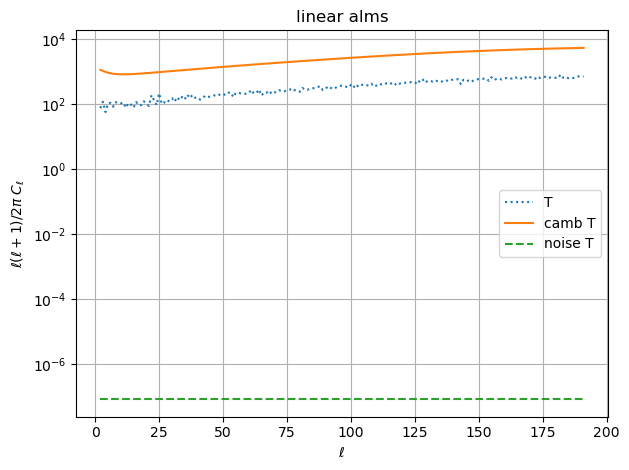

In [10]:
plot_cl_alm(
    core,
    alm_l[0],
    title="linear alms",
    # labels=plt_labels,
    plot_camb=True,
    plot_noise=True,
    plot_full_camb=False,
    show=True,
)

# plot_cl_alm(
#     core,
#     alm_nl[[0]],
#     title="non-linear alms",
#     plot_camb=False,
#     plot_noise=True,
#     plot_full_camb=False,
#     show=True,
# )

22-Jan-25 08:52:45 - mlpng.utils.plots - INFO - Mean ratio of alm T: 3.4980831407810336e+16
22-Jan-25 08:52:45 - mlpng.utils.plots - INFO - Mean ratio of elsner T: 13330.376458197408


ValueError: Number of alms must match number of elsner alms. Got (1, 18528) alms and (18528,) elsner alms.

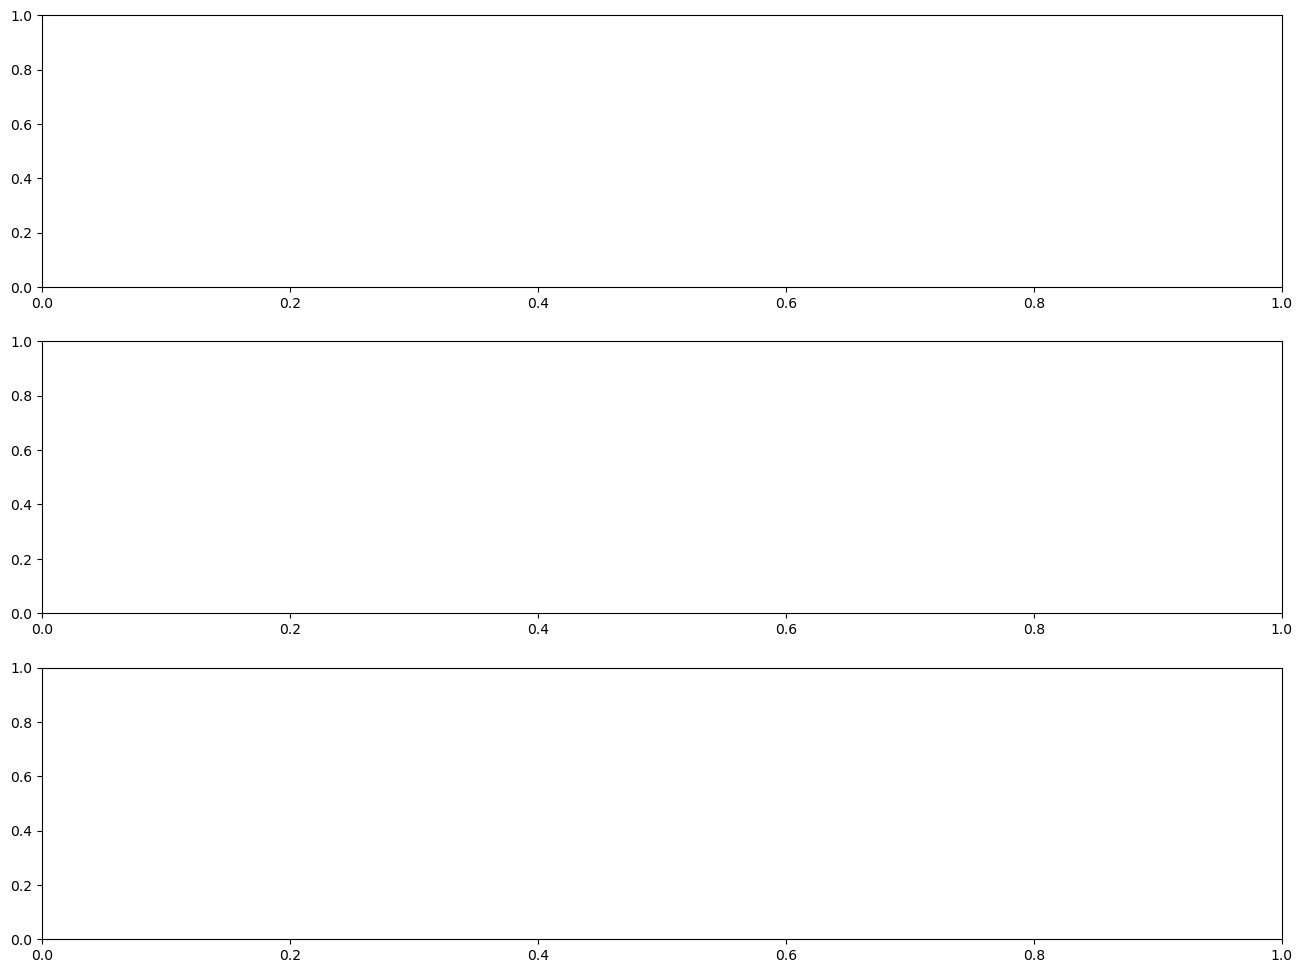

In [11]:
sim = [core.rng.integers(core.nsims)]
eidx = core.rng.integers(1, 1001)
plot_elsner_comp(
    core,
    alm_l[sim],
    alm_nl[sim],
    index=eidx,
    show=True,
    plot_func=plt.semilogy,
)
plot_elsner_comp(
    core,
    alm_l[sim],
    alm_nl[sim],
    index=eidx,
    show=True,
    plot_func=plt.plot,
)
plot_elsner_comp(
    core,
    alm_l[sim],
    alm_nl[sim],
    index=eidx,
    show=True,
    plot_func=plt.loglog,
)